In [20]:
import numpy as np
import pickle
import torch
import PIL
from PIL import Image
from io import BytesIO
from tqdm import tqdm
import matplotlib.pyplot as plt
import random
from hashlib import md5
import csv
import os
import scipy
import scipy.ndimage
import tempfile
from tqdm.auto import tqdm
import cv2
import dlib

In [31]:
def has_value_other_than_negative_one(var):
    # If var is a list, tuple, or set, check each element
    if isinstance(var, (list, tuple, set)):
        return any(item != -1 for item in var)
    
    # If var is a dictionary, check each value
    elif isinstance(var, dict):
        return any(value != -1 for value in var.values())
    
    # If var is a number, directly compare it
    elif isinstance(var, (int, float)):
        return var != -1
    
    # For objects or other types, check if they have a __dict__ (attributes)
    elif hasattr(var, '__dict__'):
        return any(value != -1 for value in vars(var).values())
    
    # For any other type, return False if it equals -1, otherwise True
    return var != -1
def load_bin(path):
    print("Loading bin:", path)
    try:
        with open(path, "rb") as f:
            bins, issame_list = pickle.load(f)  # py2
    except UnicodeDecodeError:
        with open(path, "rb") as f:
            bins, issame_list = pickle.load(f, encoding="bytes")  # py3

    # Step 1: Determine the maximum width and height from all images
    max_width, max_height = 0, 0
    for _bin in bins:
        img = Image.open(BytesIO(_bin))
        width, height = img.size
        max_width = max(max_width, width)
        max_height = max(max_height, height)

    print(f"Determined max image dimensions: {max_width}x{max_height}")

    # Step 2: Create tensors with the determined maximum image size
    data_list = []
    for flip in [0, 1]:
        # Shape: (num_pairs, 2 images per pair, 3 channels, max_height, max_width)
        data = torch.empty((len(issame_list), 2, 3, max_height, max_width))
        data_list.append(data)

    # Step 3: Load each image, resize to original dimensions, and pad if necessary
    for pair_idx in tqdm(range(len(issame_list))):
        for img_idx in range(2):  # 0 and 1 for each image in the pair
            _bin = bins[pair_idx * 2 + img_idx]
            img = Image.open(BytesIO(_bin))

            # Convert image to a numpy array in (3, H, W) format
            img_np = np.array(img).transpose((2, 0, 1))  # (H, W, 3) -> (3, H, W)

            # Prepare an empty canvas with maximum dimensions, filled with zeros (black padding)
            padded_img = np.zeros((3, max_height, max_width), dtype=np.uint8)

            # Place the original image onto the padded canvas
            orig_height, orig_width = img_np.shape[1], img_np.shape[2]
            padded_img[:, :orig_height, :orig_width] = img_np

            # Store original and flipped images in `data_list`
            for flip in [0, 1]:
                if flip == 1:
                    flipped_img = np.flip(padded_img, axis=2)  # Flip horizontally
                    data_list[flip][pair_idx, img_idx] = torch.from_numpy(flipped_img.copy())
                else:
                    data_list[flip][pair_idx, img_idx] = torch.from_numpy(padded_img.copy())

    print("Data shape for each flip:", data_list[0].shape)  # Should be (num_pairs, 2, 3, max_height, max_width)
    print("Same list shape:", len(issame_list))
    return data_list, issame_list
def display_random_pairs(data_list, issame_list):
    # Convert `issame_list` to a list of indices for genuine and impostor pairs
    genuine_indices = [i for i, same in enumerate(issame_list) if same]
    impostor_indices = [i for i, same in enumerate(issame_list) if not same]

    # Randomly select two indices from genuine and impostor lists
    selected_genuine_indices = random.sample(genuine_indices, 2)
    selected_impostor_indices = random.sample(impostor_indices, 2)
    
    # Select data from the non-flipped version (data_list[0])
    selected_indices = selected_genuine_indices + selected_impostor_indices
    selected_pairs = [data_list[0][idx] for idx in selected_indices]  # (len(issame_list), 2, 3, H, W)

    # Plot the pairs
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))  # 2 rows, 4 columns (2 genuine pairs + 2 impostor pairs)
    fig.suptitle("Random Genuine and Impostor Pairs", fontsize=16)

    for i, pair in enumerate(selected_pairs):
        label = "Genuine" if i < 2 else "Impostor"
        
        # Display both images in the pair
        for j in range(2):
            image = pair[j].permute(1, 2, 0).numpy()  # (3, H, W) -> (H, W, 3)
            ax = axs[i // 2, i * 2 % 4 + j]
            ax.imshow(image.astype("uint8"))
            ax.axis("off")
            if j == 0:
                ax.set_title(label)

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Make room for the title
    plt.show()
def pil_to_cv2(pil_image):
    # Convert PIL Image to a NumPy array
    img_np = np.array(pil_image)
    
    # If the image has an alpha channel (RGBA), remove it
    if img_np.shape[-1] == 4:
        img_np = img_np[:, :, :3]
    
    # Convert RGB to BGR (OpenCV's default color format)
    cv2_image = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
    return cv2_image
# download model from: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
predictor = dlib.shape_predictor('./model_dlib/shape_predictor_68_face_landmarks.dat')
face_detector2 = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')
# Global variables to store rectangles for averaging and standard deviation
rectangles_list = []
def get_face_bbox(face_detector, image):
    """
    Detects a face in the image and returns bounding box coordinates as dlib.rectangle objects.
    
    :param face_detector: A face detector object from OpenCV (e.g., cv2.CascadeClassifier)
    :param image: Input PIL image
    :return: A list of bounding boxes as dlib.rectangle objects
    """
    # Convert the PIL image to OpenCV format
    cv2_image = pil_to_cv2(image)

    # Convert the image to grayscale for face detection
    gray = cv2.cvtColor(cv2_image, cv2.COLOR_BGR2GRAY)
    
    # Detect faces in the image using OpenCV's face detector
    faces = face_detector.detectMultiScale(gray)
    
    # Convert each bounding box to dlib.rectangle format
    dlib_rectangles = []
    for (x, y, w, h) in faces:
        dlib_rectangles.append(dlib.rectangle(left=x, top=y, right=x + w, bottom=y + h))
    
    return dlib_rectangles
def get_average_bbox_and_std():
    # Calculate average and standard deviation if we have more than one rectangle
    if len(rectangles_list) > 1:
        rect_coords = np.array([[r.left(), r.top(), r.right(), r.bottom()] for r in rectangles_list])
        avg_rect_coords = np.mean(rect_coords, axis=0)
        std_dev_rect_coords = np.std(rect_coords, axis=0)
        avg_rect = dlib.rectangle(
            int(avg_rect_coords[0]), int(avg_rect_coords[1]),
            int(avg_rect_coords[2]), int(avg_rect_coords[3])
        )
        std_dev_rect = std_dev_rect_coords  # Standard deviation in each coordinate
    else:
        avg_rect = rectangles_list[0]
        std_dev_rect = np.zeros(4)  # No deviation with only one rectangle
    return avg_rect,std_dev_rect

def get_landmark(filepath):
#def get_landmark(pil_image):
    """get landmark with dlib
    :return: np.array shape=(68, 2)
    """
    detector = dlib.get_frontal_face_detector()

    try:
        img = dlib.load_rgb_image(filepath)
    except RuntimeError: # PPM files not supported by dlib
        import cv2
        img = cv2.imread(filepath)
    # Create a temporary file to save the image
    '''with tempfile.NamedTemporaryFile(suffix=".png") as temp_file:
        # Save the PIL image as a PNG to the temporary file
        pil_image.save(temp_file.name, format="PNG")
        
        # Load the image using dlib's load_rgb_image
        img = dlib.load_rgb_image(temp_file.name)'''
    dets = detector(img, 1)
    if len(dets)==0:
        dets = get_face_bbox(face_detector2, img)
    if len(dets)==0:
        avg_det, std_det = get_average_bbox_and_std()
        print("Average Detection for image {}: Left: {} Top: {} Right: {} Bottom: {} STD: {}".format(
            filepath, avg_det.left(), avg_det.top(), avg_det.right(), avg_det.bottom(), std_det))
        dets = [avg_det]
    else:
        # Use the first detected face for consistency
        det = dets[0]
        rectangles_list.append(det)  # Append detected rectangle for statistics

    #print("Number of faces detected: {}".format(len(dets)))
    for k, d in enumerate(dets):
        #print("Detection {}: Left: {} Top: {} Right: {} Bottom: {}".format(
            #k, d.left(), d.top(), d.right(), d.bottom()))
        # Get the landmarks/parts for the face in box d.
        shape = predictor(img, d)
        #print("Part 0: {}, Part 1: {} ...".format(shape.part(0), shape.part(1)))


    t = list(shape.parts())
    a = []
    for tt in t:
        a.append([tt.x, tt.y])
    lm = np.array(a)
    # lm is a shape=(68,2) np.array
    return lm

    
def align_face(filepath):
    """
    :param filepath: str
    :return: PIL Image
    """

    lm = get_landmark(filepath)
    if lm is None:
        return None
    
    lm_chin          = lm[0  : 17]  # left-right
    lm_eyebrow_left  = lm[17 : 22]  # left-right
    lm_eyebrow_right = lm[22 : 27]  # left-right
    lm_nose          = lm[27 : 31]  # top-down
    lm_nostrils      = lm[31 : 36]  # top-down
    lm_eye_left      = lm[36 : 42]  # left-clockwise
    lm_eye_right     = lm[42 : 48]  # left-clockwise
    lm_mouth_outer   = lm[48 : 60]  # left-clockwise
    lm_mouth_inner   = lm[60 : 68]  # left-clockwise

    # Calculate auxiliary vectors.
    eye_left     = np.mean(lm_eye_left, axis=0)
    eye_right    = np.mean(lm_eye_right, axis=0)
    eye_avg      = (eye_left + eye_right) * 0.5
    eye_to_eye   = eye_right - eye_left
    mouth_left   = lm_mouth_outer[0]
    mouth_right  = lm_mouth_outer[6]
    mouth_avg    = (mouth_left + mouth_right) * 0.5
    eye_to_mouth = mouth_avg - eye_avg

    # Choose oriented crop rectangle.
    x = eye_to_eye - np.flipud(eye_to_mouth) * [-1, 1]
    x /= np.hypot(*x)
    x *= max(np.hypot(*eye_to_eye) * 2.0, np.hypot(*eye_to_mouth) * 1.8)
    y = np.flipud(x) * [-1, 1]
    c = eye_avg + eye_to_mouth * 0.1
    quad = np.stack([c - x - y, c - x + y, c + x + y, c + x - y])
    qsize = np.hypot(*x) * 2


    # read image
    img = PIL.Image.open(filepath)

    output_size=1024
    transform_size=4096
    enable_padding=True

    # Shrink.
    shrink = int(np.floor(qsize / output_size * 0.5))
    if shrink > 1:
        rsize = (int(np.rint(float(img.size[0]) / shrink)), int(np.rint(float(img.size[1]) / shrink)))
        img = img.resize(rsize, PIL.Image.LANCZOS)
        quad /= shrink
        qsize /= shrink

    # Crop.
    border = max(int(np.rint(qsize * 0.1)), 3)
    crop = (int(np.floor(min(quad[:,0]))), int(np.floor(min(quad[:,1]))), int(np.ceil(max(quad[:,0]))), int(np.ceil(max(quad[:,1]))))
    crop = (max(crop[0] - border, 0), max(crop[1] - border, 0), min(crop[2] + border, img.size[0]), min(crop[3] + border, img.size[1]))
    if crop[2] - crop[0] < img.size[0] or crop[3] - crop[1] < img.size[1]:
        img = img.crop(crop)
        quad -= crop[0:2]

    # Pad.
    pad = (int(np.floor(min(quad[:,0]))), int(np.floor(min(quad[:,1]))), int(np.ceil(max(quad[:,0]))), int(np.ceil(max(quad[:,1]))))
    pad = (max(-pad[0] + border, 0), max(-pad[1] + border, 0), max(pad[2] - img.size[0] + border, 0), max(pad[3] - img.size[1] + border, 0))
    if enable_padding and max(pad) > border - 4:
        pad = np.maximum(pad, int(np.rint(qsize * 0.3)))
        img = np.pad(np.float32(img), ((pad[1], pad[3]), (pad[0], pad[2]), (0, 0)), 'reflect')
        h, w, _ = img.shape
        y, x, _ = np.ogrid[:h, :w, :1]
        mask = np.maximum(1.0 - np.minimum(np.float32(x) / pad[0], np.float32(w-1-x) / pad[2]), 1.0 - np.minimum(np.float32(y) / pad[1], np.float32(h-1-y) / pad[3]))
        blur = qsize * 0.02
        img += (scipy.ndimage.gaussian_filter(img, [blur, blur, 0]) - img) * np.clip(mask * 3.0 + 1.0, 0.0, 1.0)
        img += (np.median(img, axis=(0,1)) - img) * np.clip(mask, 0.0, 1.0)
        img = PIL.Image.fromarray(np.uint8(np.clip(np.rint(img), 0, 255)), 'RGB')
        quad += pad[:2]

    # Transform.
    img = img.transform((transform_size, transform_size), PIL.Image.QUAD, (quad + 0.5).flatten(), PIL.Image.BILINEAR)
    if output_size < transform_size:
        img = img.resize((output_size, output_size), PIL.Image.LANCZOS)

    # Save aligned image.
    return img

def save_images_and_mapping(data_list, issame_list, output_dir="LFW_benchmark", aligned=False, img_size=(200, 200)):
    if aligned:
        output_dir = output_dir + "_aligned"
    os.makedirs(output_dir, exist_ok=True)
    
    # Dictionary to keep track of unique images
    image_id_map = {}
    # Open the CSV file to save the pair information
    mapping_file = os.path.join(
        os.path.dirname(output_dir),
        f"{os.path.basename(output_dir)}_pairs_mapping_aligned.csv" if aligned else f"{os.path.basename(output_dir)}_pairs_mapping.csv"
    )
    
    with open(mapping_file, mode='w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(["PairIndex", "Image1_ID", "Image2_ID", "IsGenuine"])
        imgs_not_aligned = 0
        all_imgs = 0
        
        # Add tqdm notebook progress bar for pairs
        for pair_idx, is_genuine in enumerate(tqdm(issame_list, desc="Processing pairs", leave=True)):
            pair_images = []

            # Inner loop over the two images in each pair
            for img_idx in range(2):  # Each pair has two images
                all_imgs += 1
                image_tensor = data_list[0][pair_idx, img_idx]  # Select non-flipped version

                # Generate a unique hash for the image content to avoid duplicates
                image_bytes = BytesIO()
                image = Image.fromarray(image_tensor.permute(1, 2, 0).byte().numpy())
                
                # Resize image to the specified shape (200x200)
                image = image.resize(img_size, Image.LANCZOS)
                
                # Save image to BytesIO to create a hash
                image.save(image_bytes, format="PNG")
                image_hash = md5(image_bytes.getvalue()).hexdigest()

                # Check if the image is already saved; if not, save it
                if image_hash not in image_id_map:
                    image_name = f"img_{image_hash}.png"
                    image_path = os.path.join(output_dir, image_name)
                    image.save(image_path, format="PNG")
                    image_id_map[image_hash] = image_name  # Map hash to file name

                # Add the unique image ID (hash) to the pair list
                pair_images.append(image_hash)

            # Write pair information to the CSV file using image IDs
            writer.writerow([pair_idx, pair_images[0], pair_images[1], is_genuine])

    print('Number of imgs processed: ', all_imgs)
    print('Number of not aligned images: ', imgs_not_aligned)
    print(f"All unique images saved in '{output_dir}', and pair mappings in '{mapping_file}'.")
def align_faces_in_directory(target_dir):
    """
    Aligns all images in the target directory and saves them in a new directory with '_aligned' added to the name.

    :param target_dir: str - Path to the directory containing the images to be aligned.
    """
    # Create output directory
    output_dir = target_dir + "_aligned"
    os.makedirs(output_dir, exist_ok=True)

    # List all image files in the directory (supports various image formats)
    image_files = [f for f in os.listdir(target_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff'))]

    # Process each image with a progress bar
    for image_name in tqdm(image_files, desc="Aligning images"):
        image_path = os.path.join(target_dir, image_name)
        
        # Try to align the face in the image
        aligned_image = align_face(image_path)
        
        if aligned_image is not None:
            # Save aligned image to output directory
            aligned_image_path = os.path.join(output_dir, image_name)
            aligned_image.save(aligned_image_path)
        else:
            print(f"Warning: No face detected or alignment failed for '{image_name}'.")

    print(f"All aligned images are saved in '{output_dir}'.")


Loading bin: lfw.bin
Determined max image dimensions: 112x112


100%|██████████| 6000/6000 [00:03<00:00, 1730.91it/s]


Data shape for each flip: torch.Size([6000, 2, 3, 112, 112])
Same list shape: 6000


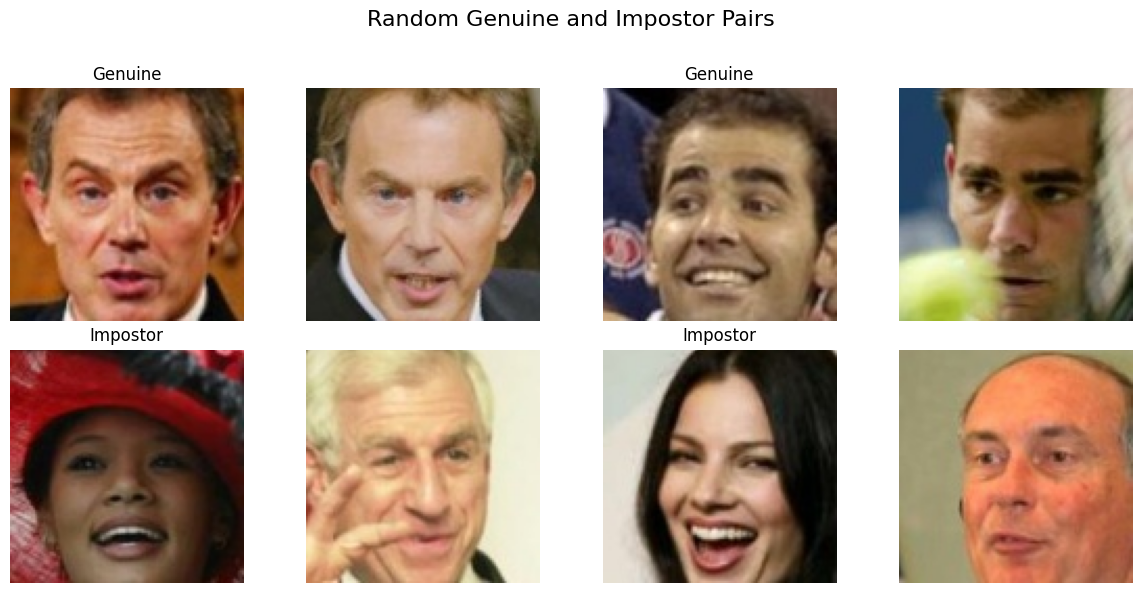

In [14]:
# Define the binary file path
binary_file_path = 'lfw.bin'
data_list, issame_list = load_bin(binary_file_path)
display_random_pairs(data_list, issame_list)

In [16]:
#save_images_and_mapping(data_list, issame_list)
save_images_and_mapping(data_list, issame_list,
                         output_dir="exp/datasets/LFW_benchmark",
                         aligned=False,img_size=(200, 200))

Processing pairs: 100%|██████████| 6000/6000 [04:20<00:00, 22.99it/s]

Number of imgs processed:  12000
Number of not aligned images:  0
All unique images saved in 'exp/datasets/LFW_benchmark', and pair mappings in 'exp/datasets/LFW_benchmark_pairs_mapping.csv'.


In [32]:
align_faces_in_directory('exp/datasets/LFW_benchmark')

Aligning images:   1%|          | 49/7701 [00:38<1:40:23,  1.27it/s]

Average Detection for image exp/datasets/LFW_benchmark/img_081d6b563bfae56842e6e0bc4e0b972b.png: Left: 31 Top: 53 Right: 172 Bottom: 194 STD: [8.46995326 9.58701572 7.97204612 8.33612892]


Aligning images:   2%|▏         | 121/7701 [01:36<1:41:47,  1.24it/s]

Average Detection for image exp/datasets/LFW_benchmark/img_d4ba844ec94ba4f5ebc5728ea6417c19.png: Left: 30 Top: 52 Right: 171 Bottom: 193 STD: [10.00144434  9.28707286  8.25368184  8.74210358]


Aligning images:   3%|▎         | 204/7701 [02:42<1:39:40,  1.25it/s]

...

Average Detection for image exp/datasets/LFW_benchmark/img_2a18c07c37636666e514f9ba47de38bb.png: Left: 29 Top: 52 Right: 170 Bottom: 193 STD: [11.03830121 10.2171966   8.08285923  8.85862499]


Aligning images:  99%|█████████▉| 7660/7701 [1:41:23<00:32,  1.27it/s]

Average Detection for image exp/datasets/LFW_benchmark/img_80b79273311206ecc7ef46a82772c35e.png: Left: 29 Top: 52 Right: 170 Bottom: 193 STD: [11.02654101 10.21538459  8.07931934  8.85546475]


Aligning images: 100%|██████████| 7701/7701 [1:41:56<00:00,  1.26it/s]

All aligned images are saved in 'exp/datasets/LFW_benchmark_aligned'.


In [ ]:
len(os.listdir('LFW_benchmark'))

7701